### Name: Abdul Hadi Saqib
### CMS: 467626
### Section: BESE-14A

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_california_housing
import os
from sklearn.linear_model import LinearRegression, SGDRegressor

In [23]:
californiaHousing = fetch_california_housing(as_frame=True)
df = californiaHousing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
featureColumns = ['MedInc', 'AveRooms', 'Latitude']
X = df[featureColumns]
y = df['MedHouseVal']

data = pd.concat([X, y], axis=1)

trainDf, restDf = train_test_split(data, test_size=0.3, random_state=42)
valDf,testDf = train_test_split(restDf, test_size=0.5, random_state=42)
print(f"Training set: {trainDf.shape}")
print(f"Validation set: {valDf.shape}")
print(f"Test set: {testDf.shape}")


os.makedirs('data/lab4', exist_ok=True)
trainDf.to_csv('data/lab4/train.csv', index=False)
valDf.to_csv('data/lab4/val.csv', index=False)
testDf.to_csv('data/lab4/test.csv', index=False)

Training set: (14448, 4)
Validation set: (3096, 4)
Test set: (3096, 4)


In [25]:
'''
Next, load the datasets into your python program and store them as NumPy arrays (Xtrain , ytrain, Xval, yval, Xtest, ytest). Next, use feature scaling to rescale the feature columns of all the datasets so that their values range from 0 to 1. Finally, print the shape of all three datasets and 5 rows of each of the datasets.
'''

trainData = pd.read_csv('data/lab4/train.csv').values
valData = pd.read_csv('data/lab4/val.csv').values
testData = pd.read_csv('data/lab4/test.csv').values

print(f"Train data Shape: {trainData.shape}" )
print(f"Val data Shape: {valData.shape}" )
print(f"Test data Shape: {testData.shape}" )

xTrain = trainData[:, :-1]
yTrain = trainData[:, -1]
xVal = valData[:, :-1]
yVal = valData[:, -1]
xTest = testData[:, :-1]
yTest = testData[:, -1]

scaler = MinMaxScaler()
xTrainScaled = scaler.fit_transform(xTrain)
xValScaled = scaler.transform(xVal)
xTestScaled = scaler.transform(xTest)

print("xTrain (scaled):")
print(xTrain[:5])
print("\nyTrain:")
print(yTrain[:5])
print("\nxVal (scaled):")
print(xVal[:5])
print("\nyVal:")
print(yVal[:5])
print("\nxTest (scaled):")
print(xTest[:5])
print("\nyTest:")
print(yTest[:5])


Train data Shape: (14448, 4)
Val data Shape: (3096, 4)
Test data Shape: (3096, 4)
xTrain (scaled):
[[ 4.1312      5.88235294 33.93      ]
 [ 2.8631      4.40120968 32.79      ]
 [ 4.2026      5.61754386 34.59      ]
 [ 3.1094      5.86956522 39.26      ]
 [ 3.3068      4.80120482 37.77      ]]

yTrain:
[1.938   1.697   2.598   1.361   5.00001]

xVal (scaled):
[[ 1.5517      3.11083123 32.76      ]
 [ 7.5695      7.99299065 37.93      ]
 [ 8.4196      7.20747664 34.15      ]
 [ 6.0634      5.93527508 33.68      ]
 [ 2.5848      3.89969605 33.99      ]]

yVal:
[1.225 3.204 4.507 2.343 1.019]

xTest (scaled):
[[ 3.1333      5.92553191 36.51      ]
 [ 2.3355      5.71172249 33.97      ]
 [ 3.3669      4.58987784 34.15      ]
 [ 3.875       4.         33.12      ]
 [ 4.3482      5.79245283 35.36      ]]

yTest:
[1.    1.188 3.761 2.    0.952]


In [26]:
from sklearn.metrics import mean_squared_error

# ============================================
# a) Batch-style (Closed-form / Normal Equation)
# ============================================
linearReg = LinearRegression()
linearReg.fit(xTrainScaled, yTrain)

yTrainPredLR = linearReg.predict(xTrainScaled)
yValPredLR = linearReg.predict(xValScaled)
yTestPredLR = linearReg.predict(xTestScaled)

mseTrain_LR = mean_squared_error(yTrain, yTrainPredLR)
mseVal_LR = mean_squared_error(yVal, yValPredLR)
mseTest_LR = mean_squared_error(yTest, yTestPredLR)

print("=" * 55)
print("a) Linear Regression (Closed-Form / Normal Equation)")
print("=" * 55)
print(f"Bias (Intercept): {linearReg.intercept_:.4f}")
print(f"Weights: {linearReg.coef_}")
print(f"\nMSE (Train): {mseTrain_LR:.4f}")
print(f"MSE (Val):   {mseVal_LR:.4f}")
print(f"MSE (Test):  {mseTest_LR:.4f}")

a) Linear Regression (Closed-Form / Normal Equation)
Bias (Intercept): 0.9037
Weights: [ 6.19884852 -4.41395262 -0.41145761]

MSE (Train): 0.6892
MSE (Val):   0.7011
MSE (Test):  0.6478


In [27]:
# ============================================
# b) Stochastic Gradient Descent (SGD)
# ============================================
sgdReg = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=42)
sgdReg.fit(xTrainScaled, yTrain)

yTrainPredSGD = sgdReg.predict(xTrainScaled)
yValPredSGD = sgdReg.predict(xValScaled)
yTestPredSGD = sgdReg.predict(xTestScaled)

mseTrain_SGD = mean_squared_error(yTrain, yTrainPredSGD)
mseVal_SGD = mean_squared_error(yVal, yValPredSGD)
mseTest_SGD = mean_squared_error(yTest, yTestPredSGD)

print("=" * 55)
print("b) SGD Regressor (Stochastic Gradient Descent)")
print("=" * 55)
print(f"Bias (Intercept): {sgdReg.intercept_[0]:.4f}")
print(f"Weights: {sgdReg.coef_}")
print(f"\nMSE (Train): {mseTrain_SGD:.4f}")
print(f"MSE (Val):   {mseVal_SGD:.4f}")
print(f"MSE (Test):  {mseTest_SGD:.4f}")

b) SGD Regressor (Stochastic Gradient Descent)
Bias (Intercept): 0.9455
Weights: [ 5.56673931  0.06851426 -0.49620591]

MSE (Train): 0.6979
MSE (Val):   0.7116
MSE (Test):  0.6572


In [28]:
# ============================================
# c) Mini-Batch Gradient Descent (partial_fit)
# ============================================
miniBatchReg = SGDRegressor(eta0=0.01, random_state=42)

batchSize = 64
nEpochs = 100

# Shuffle training data once
np.random.seed(42)
shuffleIdx = np.random.permutation(len(xTrainScaled))
xTrainShuffled = xTrainScaled[shuffleIdx]
yTrainShuffled = yTrain[shuffleIdx]

# Training loop
for epoch in range(nEpochs):
    for i in range(0, len(xTrainShuffled), batchSize):
        xBatch = xTrainShuffled[i:i + batchSize]
        yBatch = yTrainShuffled[i:i + batchSize]
        miniBatchReg.partial_fit(xBatch, yBatch)

yTrainPredMB = miniBatchReg.predict(xTrainScaled)
yValPredMB = miniBatchReg.predict(xValScaled)
yTestPredMB = miniBatchReg.predict(xTestScaled)

mseTrain_MB = mean_squared_error(yTrain, yTrainPredMB)
mseVal_MB = mean_squared_error(yVal, yValPredMB)
mseTest_MB = mean_squared_error(yTest, yTestPredMB)

print("=" * 55)
print("c) Mini-Batch Gradient Descent (batch_size=64, epochs=100)")
print("=" * 55)
print(f"Bias (Intercept): {miniBatchReg.intercept_[0]:.4f}")
print(f"Weights: {miniBatchReg.coef_}")
print(f"\nMSE (Train): {mseTrain_MB:.4f}")
print(f"MSE (Val):   {mseVal_MB:.4f}")
print(f"MSE (Test):  {mseTest_MB:.4f}")

c) Mini-Batch Gradient Descent (batch_size=64, epochs=100)
Bias (Intercept): 0.8385
Weights: [ 5.98302892 -0.34505745 -0.45479143]

MSE (Train): 0.6936
MSE (Val):   0.7091
MSE (Test):  0.6516


In [29]:
# ============================================
# Summary: Comparison of All Three Models
# ============================================
print(f"{'Model':<40} {'Train MSE':>10} {'Val MSE':>10} {'Test MSE':>10}")
print("-" * 72)
print(f"{'a) Linear Regression (Closed-Form)':<40} {mseTrain_LR:>10.4f} {mseVal_LR:>10.4f} {mseTest_LR:>10.4f}")
print(f"{'b) SGD Regressor':<40} {mseTrain_SGD:>10.4f} {mseVal_SGD:>10.4f} {mseTest_SGD:>10.4f}")
print(f"{'c) Mini-Batch GD (batch=64, epochs=100)':<40} {mseTrain_MB:>10.4f} {mseVal_MB:>10.4f} {mseTest_MB:>10.4f}")

Model                                     Train MSE    Val MSE   Test MSE
------------------------------------------------------------------------
a) Linear Regression (Closed-Form)           0.6892     0.7011     0.6478
b) SGD Regressor                             0.6979     0.7116     0.6572
c) Mini-Batch GD (batch=64, epochs=100)      0.6936     0.7091     0.6516


## Lab Task 3 – Early Stopping

In [30]:
from sklearn.metrics import mean_squared_error

# ============================================
# 1) Without Early Stopping (fixed large iterations)
# ============================================
sgdNoES = SGDRegressor(max_iter=5000, tol=None, eta0=0.01, random_state=42)
sgdNoES.fit(xTrainScaled, yTrain)

yTrainPredNoES = sgdNoES.predict(xTrainScaled)
yValPredNoES = sgdNoES.predict(xValScaled)
yTestPredNoES = sgdNoES.predict(xTestScaled)

mseTrainNoES = mean_squared_error(yTrain, yTrainPredNoES)
mseValNoES = mean_squared_error(yVal, yValPredNoES)
mseTestNoES = mean_squared_error(yTest, yTestPredNoES)

print("=" * 55)
print("1) SGD Without Early Stopping (max_iter=5000)")
print("=" * 55)
print(f"Iterations performed: {sgdNoES.n_iter_}")
print(f"Bias (Intercept): {sgdNoES.intercept_[0]:.4f}")
print(f"Weights: {sgdNoES.coef_}")
print(f"\nMSE (Train): {mseTrainNoES:.4f}")
print(f"MSE (Val):   {mseValNoES:.4f}")
print(f"MSE (Test):  {mseTestNoES:.4f}")

1) SGD Without Early Stopping (max_iter=5000)
Iterations performed: 5000
Bias (Intercept): 0.8875
Weights: [ 6.10349932 -3.05803735 -0.42607644]

MSE (Train): 0.6897
MSE (Val):   0.7032
MSE (Test):  0.6476


In [31]:
# ============================================
# 2) With Early Stopping (small patience = 5)
# ============================================
sgdSmallPatience = SGDRegressor(
    max_iter=5000, tol=1e-4, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=5,
    eta0=0.01, random_state=42
)
sgdSmallPatience.fit(xTrainScaled, yTrain)

yTrainPredSP = sgdSmallPatience.predict(xTrainScaled)
yValPredSP = sgdSmallPatience.predict(xValScaled)
yTestPredSP = sgdSmallPatience.predict(xTestScaled)

mseTrainSP = mean_squared_error(yTrain, yTrainPredSP)
mseValSP = mean_squared_error(yVal, yValPredSP)
mseTestSP = mean_squared_error(yTest, yTestPredSP)

print("=" * 55)
print("2) SGD With Early Stopping (patience=5)")
print("=" * 55)
print(f"Iterations performed: {sgdSmallPatience.n_iter_}")
print(f"Bias (Intercept): {sgdSmallPatience.intercept_[0]:.4f}")
print(f"Weights: {sgdSmallPatience.coef_}")
print(f"\nMSE (Train): {mseTrainSP:.4f}")
print(f"MSE (Val):   {mseValSP:.4f}")
print(f"MSE (Test):  {mseTestSP:.4f}")

2) SGD With Early Stopping (patience=5)
Iterations performed: 36
Bias (Intercept): 0.8740
Weights: [ 5.83708124 -0.06804337 -0.48204978]

MSE (Train): 0.6948
MSE (Val):   0.7097
MSE (Test):  0.6532


In [32]:
# ============================================
# 3) With Early Stopping (larger patience = 20)
#    Using partial_fit() loop to record MSE per epoch
# ============================================
sgdLargePatience = SGDRegressor(eta0=0.01, random_state=42)

nEpochsES = 300
patience = 20
bestValMSE = np.inf
epochsNoImprove = 0
bestEpoch = 0

trainMSEHistory = []
valMSEHistory = []

# Shuffle once
np.random.seed(42)
shuffleIdx = np.random.permutation(len(xTrainScaled))
xTrainShuffledES = xTrainScaled[shuffleIdx]
yTrainShuffledES = yTrain[shuffleIdx]

for epoch in range(1, nEpochsES + 1):
    # One full pass through training data
    sgdLargePatience.partial_fit(xTrainShuffledES, yTrainShuffledES)

    # Record MSE
    trainMSE = mean_squared_error(yTrain, sgdLargePatience.predict(xTrainScaled))
    valMSE = mean_squared_error(yVal, sgdLargePatience.predict(xValScaled))
    trainMSEHistory.append(trainMSE)
    valMSEHistory.append(valMSE)

    # Early stopping check
    if valMSE < bestValMSE:
        bestValMSE = valMSE
        epochsNoImprove = 0
        bestEpoch = epoch
    else:
        epochsNoImprove += 1

    if epochsNoImprove >= patience:
        print(f"Early stopping triggered at epoch {epoch} (best epoch: {bestEpoch})")
        break

yTrainPredLP = sgdLargePatience.predict(xTrainScaled)
yValPredLP = sgdLargePatience.predict(xValScaled)
yTestPredLP = sgdLargePatience.predict(xTestScaled)

mseTrainLP = mean_squared_error(yTrain, yTrainPredLP)
mseValLP = mean_squared_error(yVal, yValPredLP)
mseTestLP = mean_squared_error(yTest, yTestPredLP)

print("=" * 55)
print(f"3) SGD With Early Stopping (patience=20, partial_fit)")
print("=" * 55)
print(f"Iterations performed: {epoch}")
print(f"Bias (Intercept): {sgdLargePatience.intercept_[0]:.4f}")
print(f"Weights: {sgdLargePatience.coef_}")
print(f"\nMSE (Train): {mseTrainLP:.4f}")
print(f"MSE (Val):   {mseValLP:.4f}")
print(f"MSE (Test):  {mseTestLP:.4f}")

3) SGD With Early Stopping (patience=20, partial_fit)
Iterations performed: 300
Bias (Intercept): 0.8501
Weights: [ 6.01146222 -0.98519891 -0.449116  ]

MSE (Train): 0.6924
MSE (Val):   0.7076
MSE (Test):  0.6500


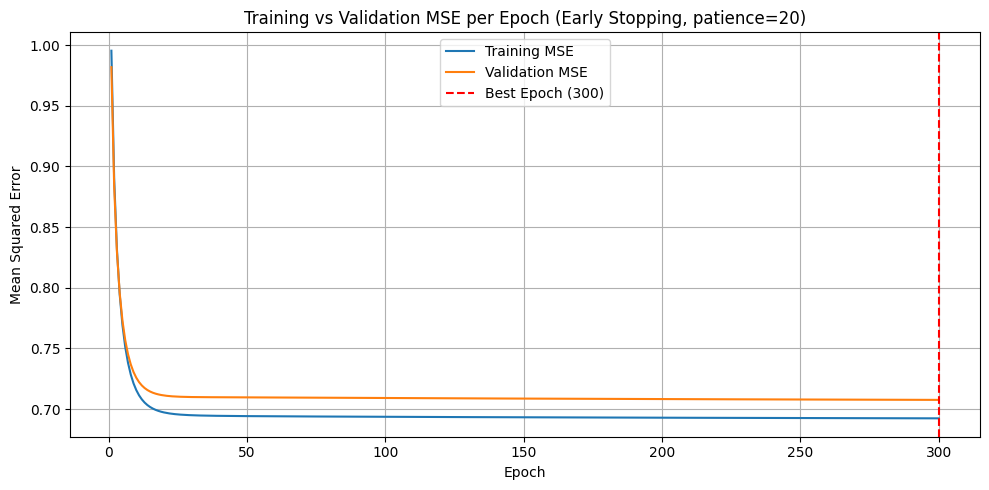

In [33]:
# ============================================
# Plot: Training MSE vs Validation MSE per Epoch
# ============================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(trainMSEHistory) + 1), trainMSEHistory, label='Training MSE')
plt.plot(range(1, len(valMSEHistory) + 1), valMSEHistory, label='Validation MSE')
plt.axvline(x=bestEpoch, color='r', linestyle='--', label=f'Best Epoch ({bestEpoch})')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation MSE per Epoch (Early Stopping, patience=20)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# ============================================
# Task 3 Summary: Comparison of Early Stopping Models
# ============================================
print(f"{'Model':<45} {'Iterations':>10} {'Train MSE':>10} {'Val MSE':>10} {'Test MSE':>10}")
print("-" * 87)
print(f"{'1) No Early Stopping (max_iter=5000)':<45} {sgdNoES.n_iter_:>10} {mseTrainNoES:>10.4f} {mseValNoES:>10.4f} {mseTestNoES:>10.4f}")
print(f"{'2) Early Stopping (patience=5)':<45} {sgdSmallPatience.n_iter_:>10} {mseTrainSP:>10.4f} {mseValSP:>10.4f} {mseTestSP:>10.4f}")
print(f"{'3) Early Stopping (patience=20, partial_fit)':<45} {epoch:>10} {mseTrainLP:>10.4f} {mseValLP:>10.4f} {mseTestLP:>10.4f}")

Model                                         Iterations  Train MSE    Val MSE   Test MSE
---------------------------------------------------------------------------------------
1) No Early Stopping (max_iter=5000)                5000     0.6897     0.7032     0.6476
2) Early Stopping (patience=5)                        36     0.6948     0.7097     0.6532
3) Early Stopping (patience=20, partial_fit)         300     0.6924     0.7076     0.6500


## Lab Task 4 – Evaluation Metrics Comparison

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================
# Pick the best early-stopping model from Task 3
# Compare val MSEs to choose the best
# ============================================
modelCandidates = {
    'No Early Stopping': (sgdNoES, mseValNoES),
    'Early Stopping (patience=5)': (sgdSmallPatience, mseValSP),
    'Early Stopping (patience=20)': (sgdLargePatience, mseValLP),
}

bestModelName = min(modelCandidates, key=lambda k: modelCandidates[k][1])
bestModel = modelCandidates[bestModelName][0]
print(f"Best model from Task 3: {bestModelName} (Val MSE: {modelCandidates[bestModelName][1]:.4f})\n")

# Predictions
yTrainPredBest = bestModel.predict(xTrainScaled)
yValPredBest = bestModel.predict(xValScaled)
yTestPredBest = bestModel.predict(xTestScaled)

# Compute metrics for each set
def computeMetrics(yTrue, yPred):
    mse = mean_squared_error(yTrue, yPred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yTrue, yPred)
    r2 = r2_score(yTrue, yPred)
    return mse, rmse, mae, r2

trainMetrics = computeMetrics(yTrain, yTrainPredBest)
valMetrics = computeMetrics(yVal, yValPredBest)
testMetrics = computeMetrics(yTest, yTestPredBest)

# Build comparison table
metricsTable = pd.DataFrame({
    'Set Type': ['Training', 'Validation', 'Testing'],
    'MSE': [trainMetrics[0], valMetrics[0], testMetrics[0]],
    'RMSE': [trainMetrics[1], valMetrics[1], testMetrics[1]],
    'MAE': [trainMetrics[2], valMetrics[2], testMetrics[2]],
    'R² Score': [trainMetrics[3], valMetrics[3], testMetrics[3]],
})

metricsTable = metricsTable.set_index('Set Type')
print(f"Evaluation Metrics for Best Model: {bestModelName}")
print("=" * 60)
print(metricsTable.to_string(float_format='%.4f'))

Best model from Task 3: No Early Stopping (Val MSE: 0.7032)

Evaluation Metrics for Best Model: No Early Stopping
              MSE   RMSE    MAE  R² Score
Set Type                                 
Training   0.6897 0.8305 0.6175    0.4852
Validation 0.7032 0.8386 0.6277    0.4602
Testing    0.6476 0.8047 0.6025    0.5103
